# Basis Pursuit / LASSO Regularization Path

We track solutions as $\lambda$ varies in $\min_x \frac12\|Ax-y\|_2^2 + \lambda\|x\|_1$.

Sparse recovery replaces an underdetermined linear system by the convex program
$$\min_x\frac12\|Ax-y\|_2^2+\lambda\|x\|_1.$$
ISTA alternates a gradient step with soft thresholding. Following the regularization path shows how $\lambda$ controls support size, data fidelity, and the transition from a null estimate to a detailed reconstruction.

The central diagnostic is therefore a three-way balance: residual norm, coefficient sparsity, and support stability. Reading these quantities together prevents a visually plausible reconstruction from being mistaken for a faithful sparse recovery.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
notebook_dir = Path('python/compressed-sensing-basis-pursuit')
OUT = notebook_dir if notebook_dir.is_dir() else Path('.')

m, n = 60, 120
A = rng.normal(size=(m, n)) / np.sqrt(m)
x0 = np.zeros(n)
supp = rng.choice(n, size=9, replace=False)
x0[supp] = rng.normal(size=9)
y = A @ x0 + 0.02*rng.normal(size=m)
lam_max = np.max(np.abs(A.T @ y))


## ISTA solver along the regularization path

For a fixed $\lambda$, iterative soft thresholding alternates a gradient step for the data term with the proximal map of the $\ell^1$ norm:
$$
x^{k+1}=\operatorname{soft}_{\tau\lambda}\!\left(x^k-\tau A^\top(Ax^k-y)\right),
$$
where $0<\tau<2/\lVert A\rVert_2^2$. Repeating the solver over decreasing values of $\lambda$ reveals how coordinates enter the LASSO solution.


In [2]:
def ista(lam, n_iter=250, step=0.9):
    x = np.zeros(n)
    L = np.linalg.norm(A, 2)**2
    tau = step / L
    for _ in range(n_iter):
        g = A.T @ (A @ x - y)
        z = x - tau * g
        x = np.sign(z) * np.maximum(np.abs(z) - lam*tau, 0)
    return x

lams = np.geomspace(lam_max, lam_max*1e-2, 24)
X = np.array([ista(lam) for lam in lams])


## Regularization path


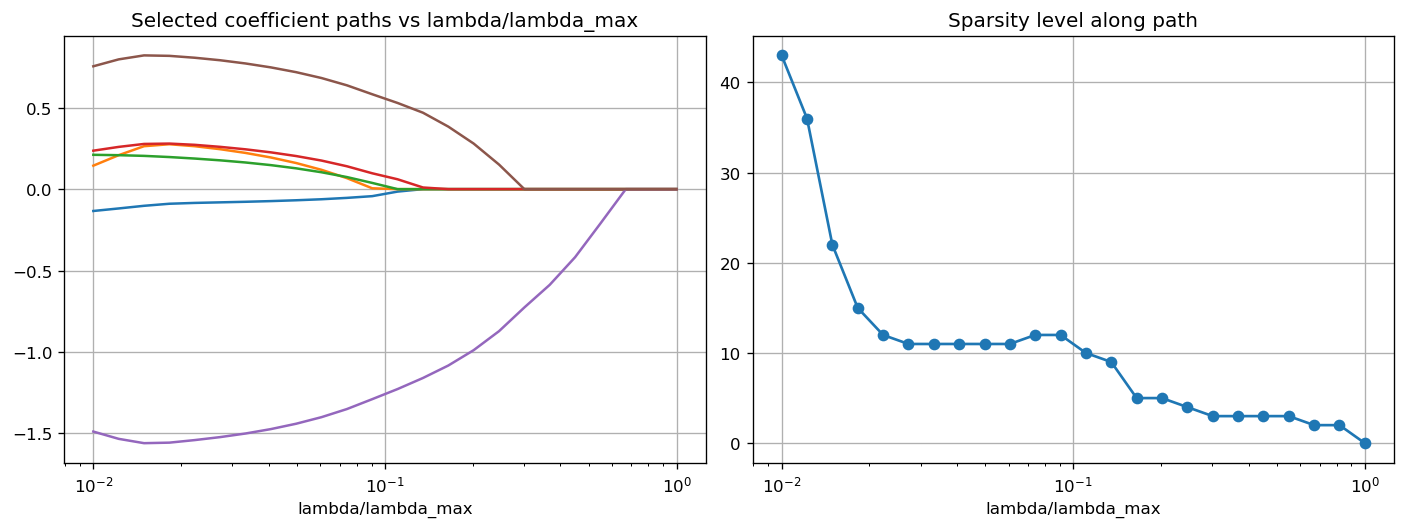

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.3), constrained_layout=True)
for j in supp[:6]:
    axes[0].plot(lams/lam_max, X[:, j], lw=1.5)
axes[0].set_xscale('log')
axes[0].set_title('Selected coefficient paths vs lambda/lambda_max')
axes[0].set_xlabel('lambda/lambda_max')

nnz = np.sum(np.abs(X) > 1e-3, axis=1)
axes[1].plot(lams/lam_max, nnz, 'o-', lw=1.6)
axes[1].set_xscale('log')
axes[1].set_title('Sparsity level along path')
axes[1].set_xlabel('lambda/lambda_max')
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical resources

- Chen, S. S., Donoho, D. L., and Saunders, M. A. (1998). Atomic decomposition by basis pursuit. *SIAM Journal on Scientific Computing*, 20, 33--61.
- Tibshirani, R. (1996). Regression shrinkage and selection via the lasso. *Journal of the Royal Statistical Society B*, 58, 267--288.
- Beck, A. and Teboulle, M. (2009). A fast iterative shrinkage-thresholding algorithm for linear inverse problems. *SIAM Journal on Imaging Sciences*, 2, 183--202.